In [1]:
print("Alhamdullilah")

Alhamdullilah


In [4]:
# ============================================================
# USED CAR PRICE PREDICTION — STAGE 6
# Neural Network + Car Name Embedding
# ============================================================

import re
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from torch.utils.data import (
    TensorDataset,
    DataLoader
)


# ============================================================
# 1. Configuration
# ============================================================

DATA_PATH = "data/car_price.csv"

RANDOM_STATE = 42

BATCH_SIZE = 32

EPOCHS = 100

LEARNING_RATE = 0.001

TARGET = "car_prices_in_rupee"

TARGET_SCALE = 1_000_000

EMBEDDING_DIM = 8


# ============================================================
# 2. Load dataset
# ============================================================

df = pd.read_csv(DATA_PATH)


# ============================================================
# 3. Parsing functions
# ============================================================

def parse_price(value):

    if pd.isna(value):
        return np.nan

    value = (
        str(value)
        .strip()
        .lower()
        .replace(",", "")
    )

    if "crore" in value:

        number = float(
            value
            .replace("crore", "")
            .strip()
        )

        return number * 10_000_000

    if "lakh" in value:

        number = float(
            value
            .replace("lakh", "")
            .strip()
        )

        return number * 100_000

    return float(value)


def parse_kms(value):

    if pd.isna(value):
        return np.nan

    return float(
        str(value)
        .replace(",", "")
        .replace(" kms", "")
        .strip()
    )


def parse_engine(value):

    if pd.isna(value):
        return np.nan

    return float(
        str(value)
        .replace(" cc", "")
        .strip()
    )


def parse_seats(value):

    if pd.isna(value):
        return np.nan

    return float(
        str(value)
        .replace(" Seats", "")
        .strip()
    )


def parse_ownership(value):

    if pd.isna(value):
        return np.nan

    match = re.search(
        r"(\d+)",
        str(value)
    )

    if match:
        return float(match.group(1))

    return np.nan


# ============================================================
# 4. Parse raw columns
# ============================================================

df[TARGET] = (
    df[TARGET]
    .apply(parse_price)
)

df["kms_driven"] = (
    df["kms_driven"]
    .apply(parse_kms)
)

df["engine"] = (
    df["engine"]
    .apply(parse_engine)
)

df["Seats"] = (
    df["Seats"]
    .apply(parse_seats)
)

df["ownership"] = (
    df["ownership"]
    .apply(parse_ownership)
)


# ============================================================
# 5. Remove identifier
# ============================================================

df = df.drop(
    columns=["s_no"]
)


# ============================================================
# 6. Separate target
# ============================================================

y = df[TARGET]


# ============================================================
# 7. Separate features
# ============================================================

X = df.drop(
    columns=[TARGET]
)


# ============================================================
# 8. Train / validation / test split
# ============================================================

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=RANDOM_STATE
)


# ============================================================
# 9. Numerical + categorical features
# ============================================================

NUMERICAL_FEATURES = [
    "kms_driven",
    "manufacture",
    "engine",
    "Seats",
    "ownership"
]

CATEGORICAL_FEATURES = [
    "fuel_type",
    "transmission"
]


# ============================================================
# 10. Process car_name
# ============================================================

# Build vocabulary ONLY from training data.
#
# This prevents validation/test information from influencing
# the vocabulary.

unique_car_names = sorted(
    X_train["car_name"]
    .dropna()
    .unique()
)


# ID 0 is reserved for unknown car names.
car_to_id = {
    car_name: index + 1
    for index, car_name
    in enumerate(unique_car_names)
}


NUM_CAR_NAMES = (
    len(car_to_id) + 1
)


def encode_car_names(series):

    return np.array(
        [
            car_to_id.get(
                car_name,
                0
            )
            for car_name in series
        ],
        dtype=np.int64
    )


car_train_ids = encode_car_names(
    X_train["car_name"]
)

car_val_ids = encode_car_names(
    X_val["car_name"]
)

car_test_ids = encode_car_names(
    X_test["car_name"]
)


print(
    "\nNumber of known car names:",
    len(car_to_id)
)

print(
    "Embedding vocabulary size:",
    NUM_CAR_NAMES
)


# ============================================================
# 11. Remove car_name before numerical preprocessing
# ============================================================

X_train_features = X_train.drop(
    columns=["car_name"]
)

X_val_features = X_val.drop(
    columns=["car_name"]
)

X_test_features = X_test.drop(
    columns=["car_name"]
)


# ============================================================
# 12. Preprocessor
# ============================================================

preprocessor = ColumnTransformer(
    transformers=[

        (
            "numerical",
            StandardScaler(),
            NUMERICAL_FEATURES
        ),

        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            CATEGORICAL_FEATURES
        )
    ]
)


# ============================================================
# 13. Fit ONLY on training data
# ============================================================

preprocessor.fit(
    X_train_features
)


# ============================================================
# 14. Transform features
# ============================================================

X_train_processed = (
    preprocessor.transform(
        X_train_features
    )
)

X_val_processed = (
    preprocessor.transform(
        X_val_features
    )
)

X_test_processed = (
    preprocessor.transform(
        X_test_features
    )
)


# ============================================================
# 15. Scale target
# ============================================================

y_train_scaled = (
    y_train.to_numpy()
    / TARGET_SCALE
)

y_val_scaled = (
    y_val.to_numpy()
    / TARGET_SCALE
)

y_test_scaled = (
    y_test.to_numpy()
    / TARGET_SCALE
)


# ============================================================
# 16. Convert features to tensors
# ============================================================

X_train_tensor = torch.tensor(
    X_train_processed,
    dtype=torch.float32
)

X_val_tensor = torch.tensor(
    X_val_processed,
    dtype=torch.float32
)

X_test_tensor = torch.tensor(
    X_test_processed,
    dtype=torch.float32
)


# ============================================================
# 17. Convert car IDs to tensors
# ============================================================

car_train_tensor = torch.tensor(
    car_train_ids,
    dtype=torch.long
)

car_val_tensor = torch.tensor(
    car_val_ids,
    dtype=torch.long
)

car_test_tensor = torch.tensor(
    car_test_ids,
    dtype=torch.long
)


# ============================================================
# 18. Target tensors
# ============================================================

y_train_tensor = torch.tensor(
    y_train_scaled,
    dtype=torch.float32
).unsqueeze(1)

y_val_tensor = torch.tensor(
    y_val_scaled,
    dtype=torch.float32
).unsqueeze(1)

y_test_tensor = torch.tensor(
    y_test_scaled,
    dtype=torch.float32
).unsqueeze(1)


# ============================================================
# 19. Dataset
# ============================================================

train_dataset = TensorDataset(
    X_train_tensor,
    car_train_tensor,
    y_train_tensor
)

val_dataset = TensorDataset(
    X_val_tensor,
    car_val_tensor,
    y_val_tensor
)

test_dataset = TensorDataset(
    X_test_tensor,
    car_test_tensor,
    y_test_tensor
)


# ============================================================
# 20. DataLoaders
# ============================================================

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)


# ============================================================
# 21. Neural Network with Embedding
# ============================================================

class CarPriceModel(nn.Module):

    def __init__(
        self,
        input_dim,
        num_car_names,
        embedding_dim
    ):

        super().__init__()


        # ----------------------------------------------------
        # Car-name embedding
        # ----------------------------------------------------

        self.car_embedding = nn.Embedding(
            num_embeddings=num_car_names,
            embedding_dim=embedding_dim
        )


        # ----------------------------------------------------
        # Existing feature network
        # ----------------------------------------------------

        self.feature_network = nn.Sequential(

            nn.Linear(
                input_dim,
                32
            ),

            nn.ReLU(),

            nn.Linear(
                32,
                16
            ),

            nn.ReLU()
        )


        # ----------------------------------------------------
        # Final prediction head
        # ----------------------------------------------------

        self.output_layer = nn.Linear(
            16 + embedding_dim,
            1
        )


    def forward(
        self,
        x_features,
        car_ids
    ):

        # Get learned representation
        car_embedding = (
            self.car_embedding(car_ids)
        )


        # Process existing features
        feature_representation = (
            self.feature_network(
                x_features
            )
        )


        # Combine both representations
        combined = torch.cat(
            [
                feature_representation,
                car_embedding
            ],
            dim=1
        )


        # Predict price
        return self.output_layer(
            combined
        )


# ============================================================
# 22. Create model
# ============================================================

input_dim = (
    X_train_tensor.shape[1]
)

model = CarPriceModel(
    input_dim=input_dim,
    num_car_names=NUM_CAR_NAMES,
    embedding_dim=EMBEDDING_DIM
)


print("\nModel:")
print(model)


# ============================================================
# 23. Loss + optimizer
# ============================================================

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)


# ============================================================
# 24. Training history
# ============================================================

train_losses = []

val_losses = []


# ============================================================
# 25. Training loop
# ============================================================

for epoch in range(EPOCHS):

    model.train()

    train_loss_sum = 0.0


    # --------------------------------------------------------
    # Training batches
    # --------------------------------------------------------

    for (
        X_batch,
        car_ids_batch,
        y_batch
    ) in train_loader:

        optimizer.zero_grad()


        predictions = model(
            X_batch,
            car_ids_batch
        )


        loss = criterion(
            predictions,
            y_batch
        )


        loss.backward()


        optimizer.step()


        train_loss_sum += (
            loss.item()
            * X_batch.size(0)
        )


    train_loss = (
        train_loss_sum
        / len(train_loader.dataset)
    )


    train_losses.append(
        train_loss
    )


    # --------------------------------------------------------
    # Validation
    # --------------------------------------------------------

    model.eval()

    val_loss_sum = 0.0


    with torch.no_grad():

        for (
            X_batch,
            car_ids_batch,
            y_batch
        ) in val_loader:

            predictions = model(
                X_batch,
                car_ids_batch
            )


            loss = criterion(
                predictions,
                y_batch
            )


            val_loss_sum += (
                loss.item()
                * X_batch.size(0)
            )


    val_loss = (
        val_loss_sum
        / len(val_loader.dataset)
    )


    val_losses.append(
        val_loss
    )


    # --------------------------------------------------------
    # Progress
    # --------------------------------------------------------

    if (
        epoch == 0
        or (epoch + 1) % 10 == 0
    ):

        print(
            f"Epoch {epoch + 1:3d}/{EPOCHS} | "
            f"Train Loss: {train_loss:.6f} | "
            f"Val Loss: {val_loss:.6f}"
        )


# ============================================================
# 26. Test prediction
# ============================================================

model.eval()

test_predictions = []


with torch.no_grad():

    for (
        X_batch,
        car_ids_batch,
        _
    ) in test_loader:

        predictions = model(
            X_batch,
            car_ids_batch
        )

        test_predictions.append(
            predictions.numpy()
        )


test_predictions = np.vstack(
    test_predictions
).reshape(-1)


# ============================================================
# 27. Convert predictions back to INR
# ============================================================

y_test_actual = (
    y_test.to_numpy()
)

y_test_predicted = (
    test_predictions
    * TARGET_SCALE
)


# ============================================================
# 28. Metrics
# ============================================================

mae = mean_absolute_error(
    y_test_actual,
    y_test_predicted
)

rmse = np.sqrt(
    mean_squared_error(
        y_test_actual,
        y_test_predicted
    )
)

r2 = r2_score(
    y_test_actual,
    y_test_predicted
)


# ============================================================
# 29. Final evaluation
# ============================================================

print("\n" + "=" * 60)
print("EMBEDDING MODEL — TEST RESULTS")
print("=" * 60)

print(
    f"MAE  : ₹{mae:,.0f}"
)

print(
    f"RMSE : ₹{rmse:,.0f}"
)

print(
    f"R²   : {r2:.4f}"
)


Number of known car names: 1587
Embedding vocabulary size: 1588

Model:
CarPriceModel(
  (car_embedding): Embedding(1588, 8)
  (feature_network): Sequential(
    (0): Linear(in_features=12, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
  )
  (output_layer): Linear(in_features=24, out_features=1, bias=True)
)
Epoch   1/100 | Train Loss: 4.047222 | Val Loss: 2.566293
Epoch  10/100 | Train Loss: 2.060253 | Val Loss: 1.859970
Epoch  20/100 | Train Loss: 1.547593 | Val Loss: 1.524444
Epoch  30/100 | Train Loss: 0.886576 | Val Loss: 1.285432
Epoch  40/100 | Train Loss: 0.458648 | Val Loss: 1.359225
Epoch  50/100 | Train Loss: 0.251966 | Val Loss: 1.554238
Epoch  60/100 | Train Loss: 0.142398 | Val Loss: 1.739203
Epoch  70/100 | Train Loss: 0.091094 | Val Loss: 1.932820
Epoch  80/100 | Train Loss: 0.066166 | Val Loss: 2.016888
Epoch  90/100 | Train Loss: 0.052832 | Val Loss: 2.089707
Epoch 100/100 | Train Loss: 0.04321

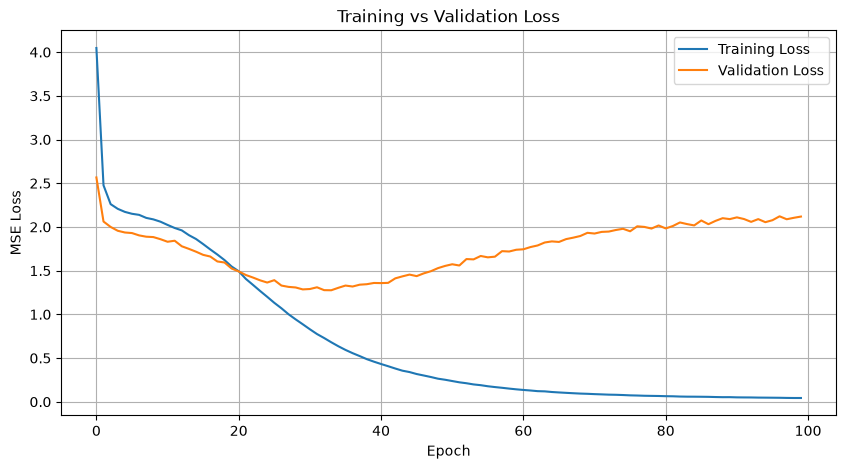

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    train_losses,
    label="Training Loss"
)

plt.plot(
    val_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.grid(True)

plt.show()

Known car names: 1587
Embedding vocabulary: 1588
Epoch   1/100 | Train Loss: 4.089856 | Val Loss: 2.600549
Epoch  10/100 | Train Loss: 2.090099 | Val Loss: 1.939224
Epoch  20/100 | Train Loss: 1.630525 | Val Loss: 1.651614
Epoch  30/100 | Train Loss: 1.084424 | Val Loss: 1.380636
Epoch  40/100 | Train Loss: 0.718678 | Val Loss: 1.152021
Epoch  50/100 | Train Loss: 0.478761 | Val Loss: 1.018444
Epoch  60/100 | Train Loss: 0.302144 | Val Loss: 0.870217
Epoch  70/100 | Train Loss: 0.179617 | Val Loss: 0.819646
Epoch  80/100 | Train Loss: 0.103753 | Val Loss: 0.761023
Epoch  90/100 | Train Loss: 0.064999 | Val Loss: 0.787550
Epoch 100/100 | Train Loss: 0.050967 | Val Loss: 0.741400

BEST MODEL
Best epoch: 100
Best validation loss: 0.7414002159054075


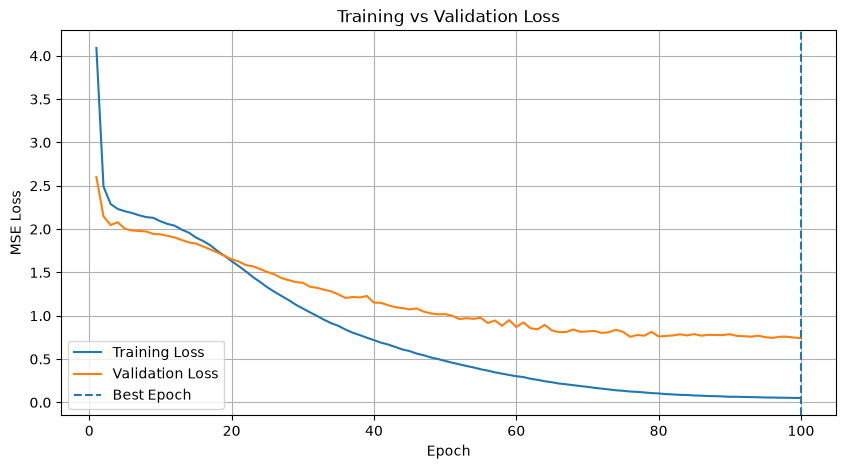


BEST MODEL — TEST RESULTS
MAE  : ₹412,251
RMSE : ₹890,607
R²   : 0.8068


In [8]:
# ============================================================
# USED CAR PRICE PREDICTION — STAGE 7
# Best Checkpoint + Learning Curve
# ============================================================

import re
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from torch.utils.data import (
    TensorDataset,
    DataLoader
)


# ============================================================
# 1. Configuration
# ============================================================

DATA_PATH = "data/car_price.csv"

RANDOM_STATE = 42

BATCH_SIZE = 32

EPOCHS = 100

LEARNING_RATE = 0.001

TARGET = "car_prices_in_rupee"

TARGET_SCALE = 1_000_000

EMBEDDING_DIM = 8


# ============================================================
# 2. Load dataset
# ============================================================

df = pd.read_csv(DATA_PATH)


# ============================================================
# 3. Parsing functions
# ============================================================

def parse_price(value):

    if pd.isna(value):
        return np.nan

    value = (
        str(value)
        .strip()
        .lower()
        .replace(",", "")
    )

    if "crore" in value:

        number = float(
            value
            .replace("crore", "")
            .strip()
        )

        return number * 10_000_000

    if "lakh" in value:

        number = float(
            value
            .replace("lakh", "")
            .strip()
        )

        return number * 100_000

    return float(value)


def parse_kms(value):

    if pd.isna(value):
        return np.nan

    return float(
        str(value)
        .replace(",", "")
        .replace(" kms", "")
        .strip()
    )


def parse_engine(value):

    if pd.isna(value):
        return np.nan

    return float(
        str(value)
        .replace(" cc", "")
        .strip()
    )


def parse_seats(value):

    if pd.isna(value):
        return np.nan

    return float(
        str(value)
        .replace(" Seats", "")
        .strip()
    )


def parse_ownership(value):

    if pd.isna(value):
        return np.nan

    match = re.search(
        r"(\d+)",
        str(value)
    )

    if match:
        return float(match.group(1))

    return np.nan


# ============================================================
# 4. Parse raw columns
# ============================================================

df[TARGET] = df[TARGET].apply(
    parse_price
)

df["kms_driven"] = df["kms_driven"].apply(
    parse_kms
)

df["engine"] = df["engine"].apply(
    parse_engine
)

df["Seats"] = df["Seats"].apply(
    parse_seats
)

df["ownership"] = df["ownership"].apply(
    parse_ownership
)


# ============================================================
# 5. Remove identifier
# ============================================================

df = df.drop(
    columns=["s_no"]
)


# ============================================================
# 6. Separate target
# ============================================================

y = df[TARGET]


# ============================================================
# 7. Separate features
# ============================================================

X = df.drop(
    columns=[TARGET]
)


# ============================================================
# 8. Train / validation / test split
# ============================================================

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=RANDOM_STATE
)


# ============================================================
# 9. Feature groups
# ============================================================

NUMERICAL_FEATURES = [
    "kms_driven",
    "manufacture",
    "engine",
    "Seats",
    "ownership"
]

CATEGORICAL_FEATURES = [
    "fuel_type",
    "transmission"
]


# ============================================================
# 10. Build car-name vocabulary
# ============================================================

unique_car_names = sorted(
    X_train["car_name"]
    .dropna()
    .unique()
)


# Reserve ID 0 for unknown cars.
car_to_id = {
    car_name: index + 1
    for index, car_name
    in enumerate(unique_car_names)
}


NUM_CAR_NAMES = (
    len(car_to_id) + 1
)


def encode_car_names(series):

    return np.array(
        [
            car_to_id.get(
                car_name,
                0
            )
            for car_name in series
        ],
        dtype=np.int64
    )


car_train_ids = encode_car_names(
    X_train["car_name"]
)

car_val_ids = encode_car_names(
    X_val["car_name"]
)

car_test_ids = encode_car_names(
    X_test["car_name"]
)


print(
    "Known car names:",
    len(car_to_id)
)

print(
    "Embedding vocabulary:",
    NUM_CAR_NAMES
)


# ============================================================
# 11. Remove car_name from normal feature pipeline
# ============================================================

X_train_features = X_train.drop(
    columns=["car_name"]
)

X_val_features = X_val.drop(
    columns=["car_name"]
)

X_test_features = X_test.drop(
    columns=["car_name"]
)


# ============================================================
# 12. Preprocessor
# ============================================================

preprocessor = ColumnTransformer(
    transformers=[

        (
            "numerical",
            StandardScaler(),
            NUMERICAL_FEATURES
        ),

        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            CATEGORICAL_FEATURES
        )
    ]
)


# ============================================================
# 13. Fit preprocessing on TRAIN only
# ============================================================

preprocessor.fit(
    X_train_features
)


# ============================================================
# 14. Transform datasets
# ============================================================

X_train_processed = (
    preprocessor.transform(
        X_train_features
    )
)

X_val_processed = (
    preprocessor.transform(
        X_val_features
    )
)

X_test_processed = (
    preprocessor.transform(
        X_test_features
    )
)


# ============================================================
# 15. Scale target
# ============================================================

y_train_scaled = (
    y_train.to_numpy()
    / TARGET_SCALE
)

y_val_scaled = (
    y_val.to_numpy()
    / TARGET_SCALE
)

y_test_scaled = (
    y_test.to_numpy()
    / TARGET_SCALE
)


# ============================================================
# 16. Feature tensors
# ============================================================

X_train_tensor = torch.tensor(
    X_train_processed,
    dtype=torch.float32
)

X_val_tensor = torch.tensor(
    X_val_processed,
    dtype=torch.float32
)

X_test_tensor = torch.tensor(
    X_test_processed,
    dtype=torch.float32
)


# ============================================================
# 17. Car ID tensors
# ============================================================

car_train_tensor = torch.tensor(
    car_train_ids,
    dtype=torch.long
)

car_val_tensor = torch.tensor(
    car_val_ids,
    dtype=torch.long
)

car_test_tensor = torch.tensor(
    car_test_ids,
    dtype=torch.long
)


# ============================================================
# 18. Target tensors
# ============================================================

y_train_tensor = torch.tensor(
    y_train_scaled,
    dtype=torch.float32
).unsqueeze(1)

y_val_tensor = torch.tensor(
    y_val_scaled,
    dtype=torch.float32
).unsqueeze(1)

y_test_tensor = torch.tensor(
    y_test_scaled,
    dtype=torch.float32
).unsqueeze(1)


# ============================================================
# 19. Datasets
# ============================================================

train_dataset = TensorDataset(
    X_train_tensor,
    car_train_tensor,
    y_train_tensor
)

val_dataset = TensorDataset(
    X_val_tensor,
    car_val_tensor,
    y_val_tensor
)

test_dataset = TensorDataset(
    X_test_tensor,
    car_test_tensor,
    y_test_tensor
)


# ============================================================
# 20. DataLoaders
# ============================================================

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)


# ============================================================
# 21. Model
# ============================================================

class CarPriceModel(nn.Module):

    def __init__(
        self,
        input_dim,
        num_car_names,
        embedding_dim
    ):

        super().__init__()

        self.car_embedding = nn.Embedding(
            num_embeddings=num_car_names,
            embedding_dim=embedding_dim
        )

        self.feature_network = nn.Sequential(

            nn.Linear(
                input_dim,
                32
            ),

            nn.ReLU(),

            nn.Linear(
                32,
                16
            ),

            nn.ReLU()
        )

        self.output_layer = nn.Linear(
            16 + embedding_dim,
            1
        )


    def forward(
        self,
        x_features,
        car_ids
    ):

        car_embedding = (
            self.car_embedding(car_ids)
        )

        feature_representation = (
            self.feature_network(
                x_features
            )
        )

        combined = torch.cat(
            [
                feature_representation,
                car_embedding
            ],
            dim=1
        )

        return self.output_layer(
            combined
        )


# ============================================================
# 22. Create model
# ============================================================

input_dim = (
    X_train_tensor.shape[1]
)

model = CarPriceModel(
    input_dim=input_dim,
    num_car_names=NUM_CAR_NAMES,
    embedding_dim=EMBEDDING_DIM
)


# ============================================================
# 23. Loss + optimizer
# ============================================================

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)


# ============================================================
# 24. Training history
# ============================================================

train_losses = []

val_losses = []


# ============================================================
# 25. Best checkpoint variables
# ============================================================

best_val_loss = float("inf")

best_epoch = None

best_model_state = None


# ============================================================
# 26. Training
# ============================================================

for epoch in range(EPOCHS):

    # --------------------------------------------------------
    # TRAIN
    # --------------------------------------------------------

    model.train()

    train_loss_sum = 0.0


    for (
        X_batch,
        car_ids_batch,
        y_batch
    ) in train_loader:

        optimizer.zero_grad()


        predictions = model(
            X_batch,
            car_ids_batch
        )


        loss = criterion(
            predictions,
            y_batch
        )


        loss.backward()


        optimizer.step()


        train_loss_sum += (
            loss.item()
            * X_batch.size(0)
        )


    train_loss = (
        train_loss_sum
        / len(train_loader.dataset)
    )


    # --------------------------------------------------------
    # VALIDATE
    # --------------------------------------------------------

    model.eval()

    val_loss_sum = 0.0


    with torch.no_grad():

        for (
            X_batch,
            car_ids_batch,
            y_batch
        ) in val_loader:

            predictions = model(
                X_batch,
                car_ids_batch
            )


            loss = criterion(
                predictions,
                y_batch
            )


            val_loss_sum += (
                loss.item()
                * X_batch.size(0)
            )


    val_loss = (
        val_loss_sum
        / len(val_loader.dataset)
    )


    # --------------------------------------------------------
    # Store history
    # --------------------------------------------------------

    train_losses.append(
        train_loss
    )

    val_losses.append(
        val_loss
    )


    # --------------------------------------------------------
    # Save best model
    # --------------------------------------------------------

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        best_epoch = epoch + 1

        best_model_state = copy.deepcopy(
            model.state_dict()
        )


    # --------------------------------------------------------
    # Progress
    # --------------------------------------------------------

    if (
        epoch == 0
        or (epoch + 1) % 10 == 0
    ):

        print(
            f"Epoch {epoch + 1:3d}/{EPOCHS} | "
            f"Train Loss: {train_loss:.6f} | "
            f"Val Loss: {val_loss:.6f}"
        )


# ============================================================
# 27. Restore BEST model
# ============================================================

model.load_state_dict(
    best_model_state
)


print("\n" + "=" * 60)
print("BEST MODEL")
print("=" * 60)

print(
    "Best epoch:",
    best_epoch
)

print(
    "Best validation loss:",
    best_val_loss
)


# ============================================================
# 28. Plot learning curves
# ============================================================

plt.figure(
    figsize=(10, 5)
)

plt.plot(
    range(1, EPOCHS + 1),
    train_losses,
    label="Training Loss"
)

plt.plot(
    range(1, EPOCHS + 1),
    val_losses,
    label="Validation Loss"
)

plt.axvline(
    best_epoch,
    linestyle="--",
    label="Best Epoch"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "MSE Loss"
)

plt.title(
    "Training vs Validation Loss"
)

plt.legend()

plt.grid(True)

plt.show()


# ============================================================
# 29. Test evaluation
# ============================================================

model.eval()

test_predictions = []


with torch.no_grad():

    for (
        X_batch,
        car_ids_batch,
        _
    ) in test_loader:

        predictions = model(
            X_batch,
            car_ids_batch
        )

        test_predictions.append(
            predictions.numpy()
        )


test_predictions = np.vstack(
    test_predictions
).reshape(-1)


# ============================================================
# 30. Convert predictions to INR
# ============================================================

y_test_actual = (
    y_test.to_numpy()
)

y_test_predicted = (
    test_predictions
    * TARGET_SCALE
)


# ============================================================
# 31. Metrics
# ============================================================

mae = mean_absolute_error(
    y_test_actual,
    y_test_predicted
)

rmse = np.sqrt(
    mean_squared_error(
        y_test_actual,
        y_test_predicted
    )
)

r2 = r2_score(
    y_test_actual,
    y_test_predicted
)


# ============================================================
# 32. Final results
# ============================================================

print("\n" + "=" * 60)
print("BEST MODEL — TEST RESULTS")
print("=" * 60)

print(
    f"MAE  : ₹{mae:,.0f}"
)

print(
    f"RMSE : ₹{rmse:,.0f}"
)

print(
    f"R²   : {r2:.4f}"
)

Known car names: 1587
Embedding vocabulary: 1588
Epoch   1/100 | Train Loss: 3.994073 | Val Loss: 2.734501
Epoch  10/100 | Train Loss: 1.995463 | Val Loss: 1.873895
Epoch  20/100 | Train Loss: 1.415646 | Val Loss: 1.588935
Epoch  30/100 | Train Loss: 0.888346 | Val Loss: 1.421543
Epoch  40/100 | Train Loss: 0.532651 | Val Loss: 1.370883
Epoch  50/100 | Train Loss: 0.327250 | Val Loss: 1.338087
Epoch  60/100 | Train Loss: 0.206253 | Val Loss: 1.282702
Epoch  70/100 | Train Loss: 0.130955 | Val Loss: 1.182681
Epoch  80/100 | Train Loss: 0.088093 | Val Loss: 1.181280
Epoch  90/100 | Train Loss: 0.063158 | Val Loss: 1.086625
Epoch 100/100 | Train Loss: 0.048392 | Val Loss: 1.071383

BEST MODEL
Best epoch: 99
Best validation loss: 1.014203847247427


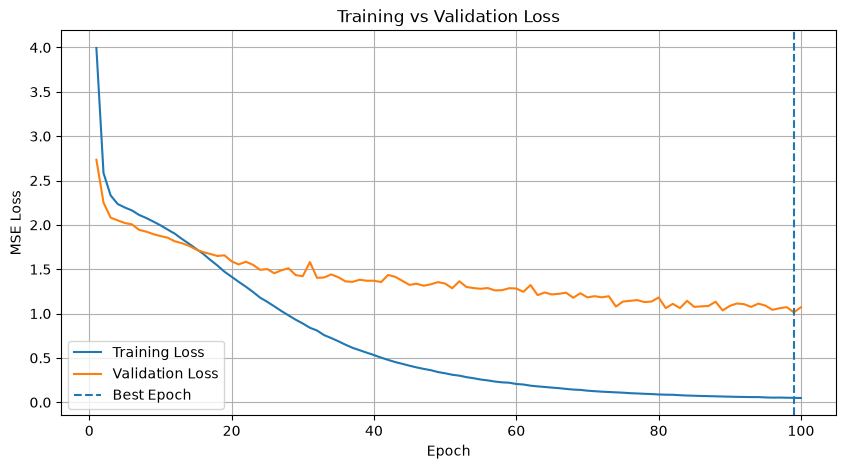


BEST MODEL — TEST RESULTS
MAE  : ₹479,198
RMSE : ₹1,050,938
R²   : 0.7310


In [9]:
# ============================================================
# USED CAR PRICE PREDICTION — STAGE 7
# Best Checkpoint + Learning Curve
# ============================================================

import re
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from torch.utils.data import (
    TensorDataset,
    DataLoader
)


# ============================================================
# 1. Configuration
# ============================================================

DATA_PATH = "data/car_price.csv"

RANDOM_STATE = 42

BATCH_SIZE = 32

EPOCHS = 100

LEARNING_RATE = 0.001

TARGET = "car_prices_in_rupee"

TARGET_SCALE = 1_000_000

EMBEDDING_DIM = 8


# ============================================================
# 2. Load dataset
# ============================================================

df = pd.read_csv(DATA_PATH)


# ============================================================
# 3. Parsing functions
# ============================================================

def parse_price(value):

    if pd.isna(value):
        return np.nan

    value = (
        str(value)
        .strip()
        .lower()
        .replace(",", "")
    )

    if "crore" in value:

        number = float(
            value
            .replace("crore", "")
            .strip()
        )

        return number * 10_000_000

    if "lakh" in value:

        number = float(
            value
            .replace("lakh", "")
            .strip()
        )

        return number * 100_000

    return float(value)


def parse_kms(value):

    if pd.isna(value):
        return np.nan

    return float(
        str(value)
        .replace(",", "")
        .replace(" kms", "")
        .strip()
    )


def parse_engine(value):

    if pd.isna(value):
        return np.nan

    return float(
        str(value)
        .replace(" cc", "")
        .strip()
    )


def parse_seats(value):

    if pd.isna(value):
        return np.nan

    return float(
        str(value)
        .replace(" Seats", "")
        .strip()
    )


def parse_ownership(value):

    if pd.isna(value):
        return np.nan

    match = re.search(
        r"(\d+)",
        str(value)
    )

    if match:
        return float(match.group(1))

    return np.nan


# ============================================================
# 4. Parse raw columns
# ============================================================

df[TARGET] = df[TARGET].apply(
    parse_price
)

df["kms_driven"] = df["kms_driven"].apply(
    parse_kms
)

df["engine"] = df["engine"].apply(
    parse_engine
)

df["Seats"] = df["Seats"].apply(
    parse_seats
)

df["ownership"] = df["ownership"].apply(
    parse_ownership
)


# ============================================================
# 5. Remove identifier
# ============================================================

df = df.drop(
    columns=["s_no"]
)


# ============================================================
# 6. Separate target
# ============================================================

y = df[TARGET]


# ============================================================
# 7. Separate features
# ============================================================

X = df.drop(
    columns=[TARGET]
)


# ============================================================
# 8. Train / validation / test split
# ============================================================

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=RANDOM_STATE
)


# ============================================================
# 9. Feature groups
# ============================================================

NUMERICAL_FEATURES = [
    "kms_driven",
    "manufacture",
    "engine",
    "Seats",
    "ownership"
]

CATEGORICAL_FEATURES = [
    "fuel_type",
    "transmission"
]


# ============================================================
# 10. Build car-name vocabulary
# ============================================================

unique_car_names = sorted(
    X_train["car_name"]
    .dropna()
    .unique()
)


# Reserve ID 0 for unknown cars.
car_to_id = {
    car_name: index + 1
    for index, car_name
    in enumerate(unique_car_names)
}


NUM_CAR_NAMES = (
    len(car_to_id) + 1
)


def encode_car_names(series):

    return np.array(
        [
            car_to_id.get(
                car_name,
                0
            )
            for car_name in series
        ],
        dtype=np.int64
    )


car_train_ids = encode_car_names(
    X_train["car_name"]
)

car_val_ids = encode_car_names(
    X_val["car_name"]
)

car_test_ids = encode_car_names(
    X_test["car_name"]
)


print(
    "Known car names:",
    len(car_to_id)
)

print(
    "Embedding vocabulary:",
    NUM_CAR_NAMES
)


# ============================================================
# 11. Remove car_name from normal feature pipeline
# ============================================================

X_train_features = X_train.drop(
    columns=["car_name"]
)

X_val_features = X_val.drop(
    columns=["car_name"]
)

X_test_features = X_test.drop(
    columns=["car_name"]
)


# ============================================================
# 12. Preprocessor
# ============================================================

preprocessor = ColumnTransformer(
    transformers=[

        (
            "numerical",
            StandardScaler(),
            NUMERICAL_FEATURES
        ),

        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            CATEGORICAL_FEATURES
        )
    ]
)


# ============================================================
# 13. Fit preprocessing on TRAIN only
# ============================================================

preprocessor.fit(
    X_train_features
)


# ============================================================
# 14. Transform datasets
# ============================================================

X_train_processed = (
    preprocessor.transform(
        X_train_features
    )
)

X_val_processed = (
    preprocessor.transform(
        X_val_features
    )
)

X_test_processed = (
    preprocessor.transform(
        X_test_features
    )
)


# ============================================================
# 15. Scale target
# ============================================================

y_train_scaled = (
    y_train.to_numpy()
    / TARGET_SCALE
)

y_val_scaled = (
    y_val.to_numpy()
    / TARGET_SCALE
)

y_test_scaled = (
    y_test.to_numpy()
    / TARGET_SCALE
)


# ============================================================
# 16. Feature tensors
# ============================================================

X_train_tensor = torch.tensor(
    X_train_processed,
    dtype=torch.float32
)

X_val_tensor = torch.tensor(
    X_val_processed,
    dtype=torch.float32
)

X_test_tensor = torch.tensor(
    X_test_processed,
    dtype=torch.float32
)


# ============================================================
# 17. Car ID tensors
# ============================================================

car_train_tensor = torch.tensor(
    car_train_ids,
    dtype=torch.long
)

car_val_tensor = torch.tensor(
    car_val_ids,
    dtype=torch.long
)

car_test_tensor = torch.tensor(
    car_test_ids,
    dtype=torch.long
)


# ============================================================
# 18. Target tensors
# ============================================================

y_train_tensor = torch.tensor(
    y_train_scaled,
    dtype=torch.float32
).unsqueeze(1)

y_val_tensor = torch.tensor(
    y_val_scaled,
    dtype=torch.float32
).unsqueeze(1)

y_test_tensor = torch.tensor(
    y_test_scaled,
    dtype=torch.float32
).unsqueeze(1)


# ============================================================
# 19. Datasets
# ============================================================

train_dataset = TensorDataset(
    X_train_tensor,
    car_train_tensor,
    y_train_tensor
)

val_dataset = TensorDataset(
    X_val_tensor,
    car_val_tensor,
    y_val_tensor
)

test_dataset = TensorDataset(
    X_test_tensor,
    car_test_tensor,
    y_test_tensor
)


# ============================================================
# 20. DataLoaders
# ============================================================

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)


# ============================================================
# 21. Model
# ============================================================

class CarPriceModel(nn.Module):

    def __init__(
        self,
        input_dim,
        num_car_names,
        embedding_dim
    ):

        super().__init__()

        self.car_embedding = nn.Embedding(
            num_embeddings=num_car_names,
            embedding_dim=embedding_dim
        )

        self.feature_network = nn.Sequential(

            nn.Linear(
                input_dim,
                32
            ),

            nn.ReLU(),

            nn.Linear(
                32,
                16
            ),

            nn.ReLU()
        )

        self.output_layer = nn.Linear(
            16 + embedding_dim,
            1
        )


    def forward(
        self,
        x_features,
        car_ids
    ):

        car_embedding = (
            self.car_embedding(car_ids)
        )

        feature_representation = (
            self.feature_network(
                x_features
            )
        )

        combined = torch.cat(
            [
                feature_representation,
                car_embedding
            ],
            dim=1
        )

        return self.output_layer(
            combined
        )


# ============================================================
# 22. Create model
# ============================================================

input_dim = (
    X_train_tensor.shape[1]
)

model = CarPriceModel(
    input_dim=input_dim,
    num_car_names=NUM_CAR_NAMES,
    embedding_dim=EMBEDDING_DIM
)


# ============================================================
# 23. Loss + optimizer
# ============================================================

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)


# ============================================================
# 24. Training history
# ============================================================

train_losses = []

val_losses = []


# ============================================================
# 25. Best checkpoint variables
# ============================================================

best_val_loss = float("inf")

best_epoch = None

best_model_state = None


# ============================================================
# 26. Training
# ============================================================

for epoch in range(EPOCHS):

    # --------------------------------------------------------
    # TRAIN
    # --------------------------------------------------------

    model.train()

    train_loss_sum = 0.0


    for (
        X_batch,
        car_ids_batch,
        y_batch
    ) in train_loader:

        optimizer.zero_grad()


        predictions = model(
            X_batch,
            car_ids_batch
        )


        loss = criterion(
            predictions,
            y_batch
        )


        loss.backward()


        optimizer.step()


        train_loss_sum += (
            loss.item()
            * X_batch.size(0)
        )


    train_loss = (
        train_loss_sum
        / len(train_loader.dataset)
    )


    # --------------------------------------------------------
    # VALIDATE
    # --------------------------------------------------------

    model.eval()

    val_loss_sum = 0.0


    with torch.no_grad():

        for (
            X_batch,
            car_ids_batch,
            y_batch
        ) in val_loader:

            predictions = model(
                X_batch,
                car_ids_batch
            )


            loss = criterion(
                predictions,
                y_batch
            )


            val_loss_sum += (
                loss.item()
                * X_batch.size(0)
            )


    val_loss = (
        val_loss_sum
        / len(val_loader.dataset)
    )


    # --------------------------------------------------------
    # Store history
    # --------------------------------------------------------

    train_losses.append(
        train_loss
    )

    val_losses.append(
        val_loss
    )


    # --------------------------------------------------------
    # Save best model
    # --------------------------------------------------------

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        best_epoch = epoch + 1

        best_model_state = copy.deepcopy(
            model.state_dict()
        )


    # --------------------------------------------------------
    # Progress
    # --------------------------------------------------------

    if (
        epoch == 0
        or (epoch + 1) % 10 == 0
    ):

        print(
            f"Epoch {epoch + 1:3d}/{EPOCHS} | "
            f"Train Loss: {train_loss:.6f} | "
            f"Val Loss: {val_loss:.6f}"
        )


# ============================================================
# 27. Restore BEST model
# ============================================================

model.load_state_dict(
    best_model_state
)


print("\n" + "=" * 60)
print("BEST MODEL")
print("=" * 60)

print(
    "Best epoch:",
    best_epoch
)

print(
    "Best validation loss:",
    best_val_loss
)


# ============================================================
# 28. Plot learning curves
# ============================================================

plt.figure(
    figsize=(10, 5)
)

plt.plot(
    range(1, EPOCHS + 1),
    train_losses,
    label="Training Loss"
)

plt.plot(
    range(1, EPOCHS + 1),
    val_losses,
    label="Validation Loss"
)

plt.axvline(
    best_epoch,
    linestyle="--",
    label="Best Epoch"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "MSE Loss"
)

plt.title(
    "Training vs Validation Loss"
)

plt.legend()

plt.grid(True)

plt.show()


# ============================================================
# 29. Test evaluation
# ============================================================

model.eval()

test_predictions = []


with torch.no_grad():

    for (
        X_batch,
        car_ids_batch,
        _
    ) in test_loader:

        predictions = model(
            X_batch,
            car_ids_batch
        )

        test_predictions.append(
            predictions.numpy()
        )


test_predictions = np.vstack(
    test_predictions
).reshape(-1)


# ============================================================
# 30. Convert predictions to INR
# ============================================================

y_test_actual = (
    y_test.to_numpy()
)

y_test_predicted = (
    test_predictions
    * TARGET_SCALE
)


# ============================================================
# 31. Metrics
# ============================================================

mae = mean_absolute_error(
    y_test_actual,
    y_test_predicted
)

rmse = np.sqrt(
    mean_squared_error(
        y_test_actual,
        y_test_predicted
    )
)

r2 = r2_score(
    y_test_actual,
    y_test_predicted
)


# ============================================================
# 32. Final results
# ============================================================

print("\n" + "=" * 60)
print("BEST MODEL — TEST RESULTS")
print("=" * 60)

print(
    f"MAE  : ₹{mae:,.0f}"
)

print(
    f"RMSE : ₹{rmse:,.0f}"
)

print(
    f"R²   : {r2:.4f}"
)